COHA Word2Vec — Diachronic Trajectory Visualisation
====================================================
Produces ONE plot:  "All Decades Combined: Trajectory + Context Words"

Pipeline overview
-----------------
1.  Load COHA .txt files and group documents by decade (year read from filename)
2.  Clean each document (strip COHA markup, lemmatise, remove stopwords)
3.  Sentence-tokenise each decade's cleaned text
4.  Train one Word2Vec model per decade
5.  Align all models into a shared vector space with Procrustes rotation
6.  Project the query word + its nearest neighbours through PCA and plot

Requirements
------------
    pip install gensim spacy scikit-learn scipy matplotlib seaborn
    python -m spacy download en_core_web_sm

## 0. Imports

In [25]:
import os
import re
import glob
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spacy

!pip install gensim
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from scipy.linalg import orthogonal_procrustes

sns.set_style("darkgrid")

QUERY_WORD  = "love"          # word whose trajectory to trace
COHA_GLOB   = "/content/*.txt"  # path
TOPN        = 8               # nearest neighbours shown per decade


## 1. Extract year and decade from COHA filename

In [26]:
# Extract year and decade from COHA filename
# COHA filenames follow the pattern  fic_YEAR_NNNN.txt
# e.g. fic_1847_7650.txt  →  year=1847, decade=1840

def extract_decade(filename):
    """Return the decade (e.g. 1840) parsed from a COHA filename, or None."""
    match = re.search(r'fic_(\d{4})_', filename)
    if match:
        year   = int(match.group(1))
        decade = (year // 10) * 10   # 1847 → 1840
        return decade
    return None

## 2. Load raw documents grouped by decade

In [27]:
# Load raw documents grouped by decade
# Each COHA file can contain multiple documents separated by @@NUMBER markers.
# We split on those markers so every segment becomes its own document.

file_paths = sorted(glob.glob(COHA_GLOB))
if not file_paths:
    raise FileNotFoundError(f"No .txt files found at {COHA_GLOB!r}. "
                             "Check the COHA_GLOB path above.")

raw_docs_by_decade = defaultdict(list)  # {decade: [text_segment, ...]}

for fp in file_paths:
    decade = extract_decade(os.path.basename(fp))
    if decade is None:
        continue

    with open(fp, encoding="utf-8", errors="replace") as f:
        content = f.read()

    # Split on document boundary markers (@@1234 etc.)
    parts = re.split(r"@@\d+", content)

    for part in parts:
        stripped = part.strip()
        if stripped:
            raw_docs_by_decade[decade].append(stripped)

print("Decades loaded:", sorted(raw_docs_by_decade.keys()))

Decades loaded: [1810, 1820, 1830, 1840, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000]


## 3. Text cleaning

In [28]:
# 3. Text cleaning
# Step A — COHA-specific noise removal (stage directions, markup, headers)
# Step B — spaCy lemmatisation + stopword removal, sentence by sentence

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
nlp.add_pipe("sentencizer")   # needed so spaCy splits into sentences


def coha_preprocess(text: str) -> str:
    """Remove COHA markup and dramatic-text noise."""

    # Remove redaction markers  (@ @ @ @ @ @)
    text = re.sub(r"(?:@\s*)+", " ", text)

    # Remove stage directions in parentheses
    text = re.sub(r"\([^)]*\)", " ", text)

    # Remove structural headers (ACT I, SCENE II, DRAMATIS PERSONAE …)
    headers = [
        r"Main text", r"DRAMATIS PERSON\.?", r"ACT\s+[IVXLC]+\.?",
        r"SCENE\s+[IVXLC]+", r"SCENE\s+\w+", r"CHORUS",
        r"END\s+OF\s+ACT", r"STAGE DIRECTIONS",
        r"EXITS? AND ENTRANCES?", r"RELATIVE POSITIONS?",
    ]
    for h in headers:
        text = re.sub(h, " ", text, flags=re.IGNORECASE)

    # Remove character-name prefixes  "Elph . Elphina  …"
    text = re.sub(r"\b[A-Z][a-z]{0,6}\s*\.\s*[A-Z][a-zA-Z]+\s+", " ", text)

    # Remove ALL-CAPS stage-direction labels  (R., L., ASIDE …)
    text = re.sub(r"\b[A-Z]{2,}\b\.?", " ", text)

    # Collapse whitespace
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def spacy_clean_sentence(spacy_span) -> list[str] | None:
    """
    Lemmatise one spaCy sentence span.
    Returns a list of lowercase lemmas (no stopwords, no punctuation)
    or None if fewer than 3 tokens remain.
    """
    tokens = [
        token.lemma_.lower()
        for token in spacy_span
        if not token.is_stop and token.is_alpha and len(token.text) > 1
    ]
    return tokens if len(tokens) > 2 else None

## 4. Sentence-tokenise each decade

In [29]:
# 4. Sentence-tokenise each decade
# After COHA cleaning we pass the text through spaCy.
# The sentencizer splits it into sentences; spacy_clean_sentence cleans each.
# Result: {decade: [[token, token, …], [token, …], …]}

sentences_by_decade = {}

for decade, docs in raw_docs_by_decade.items():

    # Apply COHA markup cleaning first (keeps punctuation for sentence splitting)
    prepped = [coha_preprocess(doc) for doc in docs]

    decade_sentences = []

    for spacy_doc in nlp.pipe(prepped, batch_size=200):
        for sent in spacy_doc.sents:
            cleaned = spacy_clean_sentence(sent)
            if cleaned:
                decade_sentences.append(cleaned)

    sentences_by_decade[decade] = decade_sentences
    print(f"{decade}s → {len(decade_sentences)} sentences")

1810s → 665 sentences
1820s → 332 sentences
1830s → 4981 sentences
1840s → 733 sentences
1860s → 265 sentences
1870s → 8021 sentences
1880s → 9571 sentences
1890s → 6248 sentences
1900s → 4503 sentences
1910s → 6107 sentences
1920s → 4950 sentences
1930s → 5957 sentences
1940s → 7342 sentences
1950s → 2343 sentences
1960s → 6933 sentences
1970s → 10027 sentences
1980s → 2654 sentences
1990s → 2499 sentences
2000s → 6482 sentences


## 5. Train one Word2Vec model per decade

In [19]:
# 5. Train one Word2Vec model per decade
# Parameters are tuned for a small-to-medium COHA sample.
# With the full COHA corpus (400 M words) you can raise
# min_count to 20, vector_size to 300.

models = {}

for decade, sentences in sentences_by_decade.items():
    if not sentences:
        print(f"{decade}s — no sentences, skipping.")
        continue

    print(f"Training Word2Vec for {decade}s …", end=" ")
    model = Word2Vec(
        sentences   = sentences,
        vector_size = 100,   # embedding dimensions
        window      = 5,     # context window (±5 words)
        min_count   = 3,     # ignore words appearing fewer than 3 times
        workers     = 2,
        epochs      = 30,
    )
    models[decade] = model
    print(f"vocab={len(model.wv)} words")

Training Word2Vec for 1810s … vocab=378 words
Training Word2Vec for 1820s … vocab=355 words
Training Word2Vec for 1830s … vocab=3465 words
Training Word2Vec for 1840s … vocab=576 words
Training Word2Vec for 1860s … vocab=120 words
Training Word2Vec for 1870s … vocab=4545 words
Training Word2Vec for 1880s … vocab=3938 words
Training Word2Vec for 1890s … vocab=3494 words
Training Word2Vec for 1900s … vocab=2505 words
Training Word2Vec for 1910s … vocab=2924 words
Training Word2Vec for 1920s … vocab=2125 words
Training Word2Vec for 1930s … vocab=2411 words
Training Word2Vec for 1940s … vocab=3054 words
Training Word2Vec for 1950s … vocab=1137 words
Training Word2Vec for 1960s … vocab=2244 words
Training Word2Vec for 1970s … vocab=4392 words
Training Word2Vec for 1980s … vocab=1269 words
Training Word2Vec for 1990s … vocab=1363 words
Training Word2Vec for 2000s … vocab=3108 words


## 6. Procrustes alignment — map all models into one shared space

In [20]:
# 6. Procrustes alignment — map all models into one shared space
# Each Word2Vec model trains independently, so its axes are randomly oriented.
# Procrustes finds the best rotation matrix R so that the vectors of model X
# match the vectors of the reference model as closely as possible.
#
#   aligned_vectors = current_vectors  @  R
#
# After alignment, the same word in different decades has comparable coordinates.

def align_models_to_reference(models: dict, reference_decade: int) -> dict:
    """
    Rotate every model's vectors into the coordinate system of reference_decade.

    Returns
    -------
    aligned : dict
        {decade: {word: aligned_vector_array}}
    """
    reference_wv = models[reference_decade].wv
    aligned = {}

    for decade, model in models.items():
        current_wv = model.wv

        # Only use words that appear in BOTH models (the anchor set)
        common = list(
            set(reference_wv.key_to_index) & set(current_wv.key_to_index)
        )

        if len(common) < 2:
            print(f"  Skipping {decade}s — fewer than 2 shared words.")
            continue

        ref_vecs = np.array([reference_wv[w] for w in common])
        cur_vecs = np.array([current_wv[w] for w in common])

        if decade == reference_decade:
            # The reference decade aligns to itself — no rotation needed
            aligned_vecs = cur_vecs
        else:
            # Find rotation matrix R that minimises ||cur_vecs @ R - ref_vecs||
            R, _ = orthogonal_procrustes(cur_vecs, ref_vecs)
            aligned_vecs = cur_vecs @ R

        aligned[decade] = {w: aligned_vecs[i] for i, w in enumerate(common)}

    return aligned


# Use the earliest available decade as the reference (anchor) space
reference_decade = min(models.keys())
print(f"\nAligning all models to {reference_decade}s as reference …")

aligned_vectors_by_decade = align_models_to_reference(
    models           = models,
    reference_decade = reference_decade,
)

print("Aligned decades:", sorted(aligned_vectors_by_decade.keys()))


Aligning all models to 1810s as reference …
Aligned decades: [1810, 1820, 1830, 1840, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000]


## 7. Helper — cosine similarity

In [21]:
# 7. Helper — cosine similarity

def cosine_similarity(v1: np.ndarray, v2: np.ndarray) -> float:
    """Cosine similarity between two 1-D vectors."""
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    return float(np.dot(v1, v2) / (n1 * n2))

## 8. Helper — nearest neighbours inside one aligned decade

In [22]:
# 8. Helper — nearest neighbours inside one aligned decade

def most_similar_aligned(aligned_vectors_by_decade: dict,
                          decade: int,
                          query: str,
                          topn: int = 8) -> list[tuple[str, float]]:
    """
    Return the topn words most similar to query inside the aligned
    vector space of a single decade.
    """
    if decade not in aligned_vectors_by_decade:
        return []

    vecs = aligned_vectors_by_decade[decade]
    if query not in vecs:
        return []

    qvec = vecs[query]
    sims = [
        (word, cosine_similarity(qvec, vec))
        for word, vec in vecs.items()
        if word != query
    ]
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:topn]

## 9. Trajectory + Context Words (all decades)

In [23]:
# 9. Main visualisation — Trajectory + Context Words (all decades) ─────────

def plot_trajectory_with_context(
    aligned_vectors_by_decade: dict,
    query_word: str,
    context_decades: list[int],
    topn: int = 8,
) -> None:
    """
    Plot the semantic trajectory of query_word across all decades (blue line)
    and show the topn nearest context words for each decade in context_decades
    (coloured scatter clouds connected to their decade's trajectory point).

    Parameters
    ----------
    aligned_vectors_by_decade : dict
        Output of align_models_to_reference().
    query_word : str
        The word to trace through time.
    context_decades : list of int
        Which decades to draw context-word clouds for.
        Pass all available decades for the "all decades" view.
    topn : int
        How many context words to show per decade.
    """

    # Collect all rows (main trajectory + context words)
    rows = []

    # Main trajectory: query_word's aligned vector in every decade
    for decade in sorted(aligned_vectors_by_decade.keys()):
        vecs = aligned_vectors_by_decade[decade]
        if query_word in vecs:
            rows.append({
                "word":   query_word,
                "decade": decade,
                "kind":   "main",                         # used for filtering later
                "label":  f"{query_word} {decade}s",
                "vector": vecs[query_word],
            })

    # Context clouds: topn neighbours for each selected decade
    for decade in context_decades:
        neighbours = most_similar_aligned(
            aligned_vectors_by_decade, decade, query_word, topn=topn
        )
        for word, score in neighbours:
            rows.append({
                "word":   word,
                "decade": decade,
                "kind":   "context",                      # coloured dots
                "label":  f"{word} ({decade}s)",
                "vector": aligned_vectors_by_decade[decade][word],
                "score":  score,
            })

    if len(rows) < 2:
        print(f"Not enough data to plot '{query_word}'.")
        return

    # ── ONE shared PCA for everything ────────────────────────────────────────
    # Projecting all vectors together means trajectory points and context words
    # share the same 2-D coordinate system and are directly comparable.
    all_vectors = np.array([r["vector"] for r in rows])
    pca         = PCA(n_components=2, random_state=42)
    coords      = pca.fit_transform(all_vectors)

    df = pd.DataFrame({
        "x":      coords[:, 0],
        "y":      coords[:, 1],
        "word":   [r["word"]   for r in rows],
        "decade": [r["decade"] for r in rows],
        "kind":   [r["kind"]   for r in rows],
        "label":  [r["label"]  for r in rows],
    })

    # ── Build a colour palette — one colour per decade ───────────────────────
    # We cycle through matplotlib's tab20 palette so each decade gets its own
    # colour even when there are many decades.
    available_decades = sorted(context_decades)
    base_colors       = plt.cm.tab20.colors          # 20 distinct colours
    decade_color_map  = {
        dec: base_colors[i % len(base_colors)]
        for i, dec in enumerate(available_decades)
    }

    # Plotting
    plt.figure(figsize=(16, 11))

    # 1. Main trajectory line (blue, on top)
    main_df = df[df["kind"] == "main"].sort_values("decade")
    plt.plot(
        main_df["x"], main_df["y"],
        marker="o", linewidth=2.5, color="steelblue", zorder=5,
        label=f"Trajectory of '{query_word}'",
    )
    for _, row in main_df.iterrows():
        plt.text(
            row["x"] + 0.03, row["y"] + 0.03,
            row["label"],
            fontsize=10, weight="bold", color="black", zorder=6,
        )

    # 2. Context word clouds + dashed spokes back to their trajectory point
    for decade in available_decades:
        subset = df[(df["kind"] == "context") & (df["decade"] == decade)]
        if subset.empty:
            continue

        color = decade_color_map[decade]

        # Scatter dots
        plt.scatter(
            subset["x"], subset["y"],
            s=60, color=color, alpha=0.85, zorder=3,
            label=f"{decade}s context words",
        )

        # Text labels
        for _, row in subset.iterrows():
            plt.text(
                row["x"] + 0.02, row["y"] + 0.02,
                row["label"],
                fontsize=8, color=color, alpha=0.9,
            )

        # Dashed spokes: each context word → its decade's trajectory point
        anchor = main_df[main_df["decade"] == decade]
        if not anchor.empty:
            ax_x, ax_y = anchor.iloc[0]["x"], anchor.iloc[0]["y"]
            for _, row in subset.iterrows():
                plt.plot(
                    [ax_x, row["x"]], [ax_y, row["y"]],
                    linestyle="--", linewidth=0.8,
                    alpha=0.4, color=color,
                )

    plt.title(
        f"All Decades Combined: Aligned Trajectory + Context Words for '{query_word}'",
        fontsize=14,
    )
    plt.xlabel("PCA Dimension 1",  fontsize=11)
    plt.ylabel("PCA Dimension 2",  fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.4)

    #legend: put it outside the plot area so it doesn't cover the words
    plt.legend(
        bbox_to_anchor=(1.01, 1), loc="upper left",
        fontsize=8, title="Decade", title_fontsize=9,
        framealpha=0.9,
    )
    plt.tight_layout()
    plt.show()

## 10. Run the plot

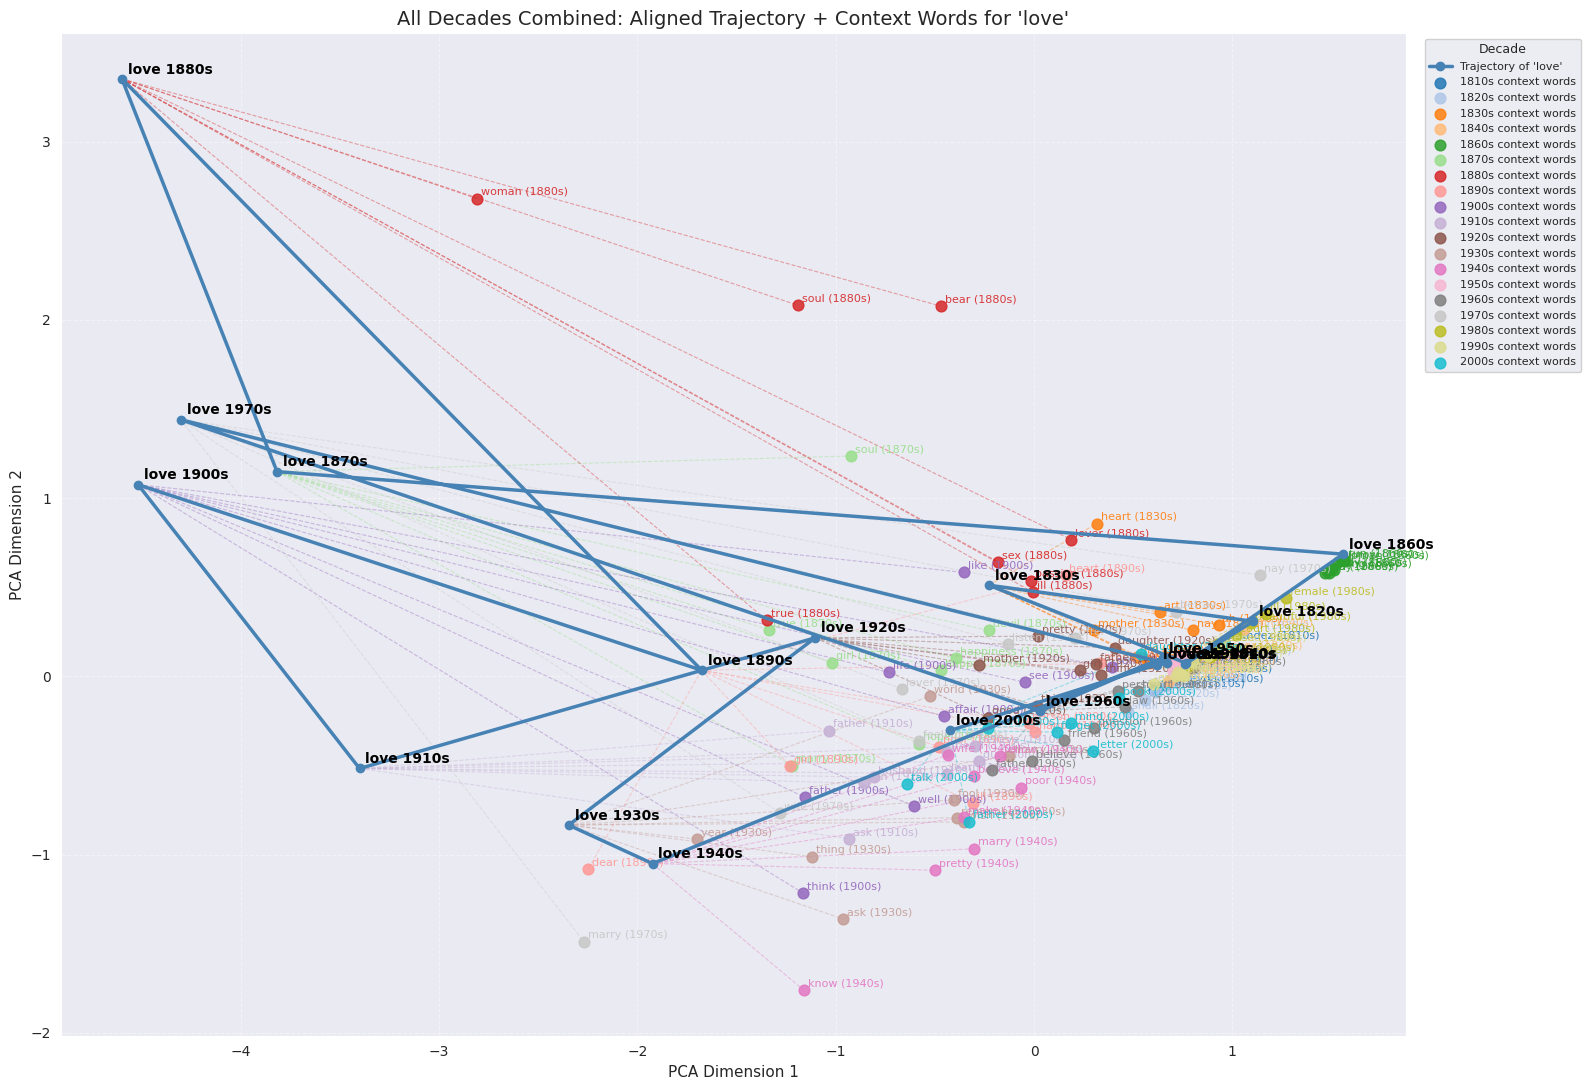

In [35]:
# Run plot

all_decades = sorted(aligned_vectors_by_decade.keys())

plot_trajectory_with_context(
    aligned_vectors_by_decade = aligned_vectors_by_decade,
    query_word                = QUERY_WORD,
    context_decades           = all_decades,   # show every decade
    topn                      = TOPN,
)

In [32]:
# Prepare data for plotting for Plotly visualization

query_word = QUERY_WORD
context_decades = all_decades # `all_decades` is already available from previous execution.
topn = TOPN

# Collect all rows (main trajectory + context words)
rows = []

# Main trajectory: query_word's aligned vector in every decade
for decade in sorted(aligned_vectors_by_decade.keys()):
    vecs = aligned_vectors_by_decade[decade]
    if query_word in vecs:
        rows.append({
            "word":   query_word,
            "decade": decade,
            "kind":   "main",
            "label":  f"{query_word} {decade}s",
            "vector": vecs[query_word],
        })

# Context clouds: topn neighbours for each selected decade
for decade in context_decades:
    neighbours = most_similar_aligned(
        aligned_vectors_by_decade, decade, query_word, topn=topn
    )
    for word, score in neighbours:
        rows.append({
            "word":   word,
            "decade": decade,
            "kind":   "context",
            "label":  f"{word} ({decade}s)",
            "vector": aligned_vectors_by_decade[decade][word],
            "score":  score,
        })

if len(rows) < 2:
    print(f"Not enough data to plot '{query_word}'.")
    # Initialize df, main_df, available_decades to empty/default to prevent further errors
    df = pd.DataFrame()
    main_df = pd.DataFrame()
    available_decades = []
else:
    # ONE shared PCA for everything
    all_vectors = np.array([r["vector"] for r in rows])
    pca         = PCA(n_components=2, random_state=42)
    coords      = pca.fit_transform(all_vectors);

    df = pd.DataFrame({
        "x":      coords[:, 0],
        "y":      coords[:, 1],
        "word":   [r["word"]   for r in rows],
        "decade": [r["decade"] for r in rows],
        "kind":   [r["kind"]   for r in rows],
        "label":  [r["label"]  for r in rows],
    });

    main_df = df[df["kind"] == "main"].sort_values("decade")
    available_decades = sorted(context_decades) # Make available_decades globally defined.

In [33]:
pip install plotly

In [34]:
import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()

# Context word clouds
for decade in available_decades:
    subset = df[(df["kind"] == "context") & (df["decade"] == decade)]
    if subset.empty:
        continue
    fig.add_trace(go.Scatter(
        x=subset["x"], y=subset["y"],
        mode="markers+text",
        name=f"{decade}s context",
        text=subset["label"],
        textposition="top right",
        textfont=dict(size=8),
        marker=dict(size=7, opacity=0.8),
        hovertext=subset["label"],   # ← appears on hover
        hoverinfo="text"
    ))

# Main trajectory line
fig.add_trace(go.Scatter(
    x=main_df["x"], y=main_df["y"],
    mode="lines+markers+text",
    name=f"Trajectory of '{query_word}'",
    text=main_df["label"],
    textposition="top right",
    textfont=dict(size=11, color="black"),
    line=dict(color="steelblue", width=2.5),
    marker=dict(size=10, color="steelblue"),
    hovertext=main_df["label"],
    hoverinfo="text"
))

fig.update_layout(
    title=f"All Decades: Trajectory + Context Words for '{query_word}'",
    xaxis_title="PCA Dimension 1",
    yaxis_title="PCA Dimension 2",
    width=1200, height=800,
    legend=dict(x=1.01, y=1)
)

fig.show()